In [ ]:
import pandas as pd
import os
import mne
import numpy as np

from typing import List, Optional
import random

import matplotlib.pyplot as plt


import mlflow

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score


from EpilepsyNet_model import *

In [365]:
def Load_raw_labeled(df):
    """
    Load the raw EEG data and labels from the dataframe.
    """
    raw_list = []
    labels = []
    for index, row in df.iterrows():
        # Load the raw EEG data
        raw = mne.io.read_raw_edf(row['edf_path'], preload=True, verbose='ERROR')
        # Append the loaded data and label to the lists
        if raw.duration>60:
            raw_list.append(raw)
            labels.append(row['epilepsy'])
        else:
            print(f"Skipping {row['edf_path']} due to insufficient duration. Duration: {raw.duration} seconds")
    return raw_list, labels

### Define train and test dataset :

In [366]:
df = pd.read_excel('eeg_metadata.xlsx')
df['epilepsy'] = df['edf_path'].apply(lambda x: 0 if 'no_epilepsy' in x else 1)
try:
    df.drop(['Unnamed: 0', 'ethnicity'], axis=1, inplace=True)
except:
    pass
df

,edf_path,subject_id,session,session_date,montage,token,patient_group,age,gender,epilepsy
0,EEG_Epilepsy/00_epilepsy/aaaaaoui/s002_2013/01...,aaaaaoui,s002,2013,01_tcp_ar,t001,epilepsy,56,M,1
1,EEG_Epilepsy/00_epilepsy/aaaaaoui/s001_2013/01...,aaaaaoui,s001,2013,01_tcp_ar,t000,epilepsy,56,M,1
2,EEG_Epilepsy/00_epilepsy/aaaaaoui/s001_2013/01...,aaaaaoui,s001,2013,01_tcp_ar,t001,epilepsy,56,M,1
3,EEG_Epilepsy/00_epilepsy/aaaaakvr/s001_2010/01...,aaaaakvr,s001,2010,01_tcp_ar,t000,epilepsy,43,F,1
4,EEG_Epilepsy/00_epilepsy/aaaaamys/s001_2012/01...,aaaaamys,s001,2012,01_tcp_ar,t000,epilepsy,44,M,1
...,...,...,...,...,...,...,...,...,...,...
2293,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s002_2012...,aaaaangg,s002,2012,01_tcp_ar,t011,no_epilepsy,57,M,0
2294,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s002_2012...,aaaaangg,s002,2012,01_tcp_ar,t005,no_epilepsy,57,M,0
2295,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s001_2012...,aaaaangg,s001,2012,01_tcp_ar,t001,no_epilepsy,57,M,0
2296,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s001_2012...,aaaaangg,s001,2012,01_tcp_ar,t000,no_epilepsy,57,M,0


In [367]:
df_pos = df[df['epilepsy'] == 1]
df_neg = df[df['epilepsy'] == 0]

print(df_pos['subject_id'].nunique(), df_neg['subject_id'].nunique())
split_pos = int(0.8 * len(df_pos['subject_id'].unique()))
print(split_pos)

split_train_pos, split_test_pos = df_pos['subject_id'].unique()[:split_pos], df_pos['subject_id'].unique()[split_pos:]

print(len(split_train_pos ), len(split_test_pos ))
##############################
split_neg = int(0.8 * len(df_neg['subject_id'].unique()))
print(split_neg)

split_train_neg, split_test_neg = df_neg['subject_id'].unique()[:split_neg], df_neg['subject_id'].unique()[split_neg:]

print(len(split_train_neg), len(split_test_neg))


100 100
80
80 20
80
80 20


In [368]:
df_train = pd.concat([df_pos[df_pos['subject_id'].isin(split_train_pos)], df_neg[df_neg['subject_id'].isin(split_train_neg)]])
print(df_train.shape, df_train['epilepsy'].value_counts())
display(df_train)

df_test = pd.concat([df_pos[df_pos['subject_id'].isin(split_test_pos)], df_neg[df_neg['subject_id'].isin(split_test_neg)]])
print(df_test.shape, df_test['epilepsy'].value_counts())
display(df_test)

(1894, 10) epilepsy
1    1464
0     430
Name: count, dtype: int64


,edf_path,subject_id,session,session_date,montage,token,patient_group,age,gender,epilepsy
0,EEG_Epilepsy/00_epilepsy/aaaaaoui/s002_2013/01...,aaaaaoui,s002,2013,01_tcp_ar,t001,epilepsy,56,M,1
1,EEG_Epilepsy/00_epilepsy/aaaaaoui/s001_2013/01...,aaaaaoui,s001,2013,01_tcp_ar,t000,epilepsy,56,M,1
2,EEG_Epilepsy/00_epilepsy/aaaaaoui/s001_2013/01...,aaaaaoui,s001,2013,01_tcp_ar,t001,epilepsy,56,M,1
3,EEG_Epilepsy/00_epilepsy/aaaaakvr/s001_2010/01...,aaaaakvr,s001,2010,01_tcp_ar,t000,epilepsy,43,F,1
4,EEG_Epilepsy/00_epilepsy/aaaaamys/s001_2012/01...,aaaaamys,s001,2012,01_tcp_ar,t000,epilepsy,44,M,1
...,...,...,...,...,...,...,...,...,...,...
2210,EEG_Epilepsy/01_no_epilepsy/aaaaalpi/s002_2011...,aaaaalpi,s002,2011,02_tcp_le,t002,no_epilepsy,29,M,0
2211,EEG_Epilepsy/01_no_epilepsy/aaaaalpi/s002_2011...,aaaaalpi,s002,2011,02_tcp_le,t003,no_epilepsy,29,M,0
2212,EEG_Epilepsy/01_no_epilepsy/aaaaalpi/s002_2011...,aaaaalpi,s002,2011,02_tcp_le,t004,no_epilepsy,29,M,0
2213,EEG_Epilepsy/01_no_epilepsy/aaaaalpi/s002_2011...,aaaaalpi,s002,2011,02_tcp_le,t005,no_epilepsy,29,M,0


(404, 10) epilepsy
1    321
0     83
Name: count, dtype: int64


,edf_path,subject_id,session,session_date,montage,token,patient_group,age,gender,epilepsy
1464,EEG_Epilepsy/00_epilepsy/aaaaaocl/s003_2013/01...,aaaaaocl,s003,2013,01_tcp_ar,t006,epilepsy,51,M,1
1465,EEG_Epilepsy/00_epilepsy/aaaaaocl/s003_2013/01...,aaaaaocl,s003,2013,01_tcp_ar,t005,epilepsy,51,M,1
1466,EEG_Epilepsy/00_epilepsy/aaaaaocl/s003_2013/01...,aaaaaocl,s003,2013,01_tcp_ar,t004,epilepsy,51,M,1
1467,EEG_Epilepsy/00_epilepsy/aaaaaocl/s003_2013/01...,aaaaaocl,s003,2013,01_tcp_ar,t000,epilepsy,51,M,1
1468,EEG_Epilepsy/00_epilepsy/aaaaaocl/s003_2013/01...,aaaaaocl,s003,2013,01_tcp_ar,t001,epilepsy,51,M,1
...,...,...,...,...,...,...,...,...,...,...
2293,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s002_2012...,aaaaangg,s002,2012,01_tcp_ar,t011,no_epilepsy,57,M,0
2294,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s002_2012...,aaaaangg,s002,2012,01_tcp_ar,t005,no_epilepsy,57,M,0
2295,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s001_2012...,aaaaangg,s001,2012,01_tcp_ar,t001,no_epilepsy,57,M,0
2296,EEG_Epilepsy/01_no_epilepsy/aaaaangg/s001_2012...,aaaaangg,s001,2012,01_tcp_ar,t000,no_epilepsy,57,M,0


In [369]:
# display df_train with 1 line per subject_id
df_train_subjects = df_train.groupby('subject_id').first().reset_index()
df_train_subjects

,subject_id,edf_path,session,session_date,montage,token,patient_group,age,gender,epilepsy
0,aaaaaanr,EEG_Epilepsy/00_epilepsy/aaaaaanr/s003_2013/01...,s003,2013,01_tcp_ar,t000,epilepsy,35,M,1
1,aaaaabdn,EEG_Epilepsy/00_epilepsy/aaaaabdn/s001_2003/02...,s001,2003,02_tcp_le,t000,epilepsy,47,F,1
2,aaaaabju,EEG_Epilepsy/00_epilepsy/aaaaabju/s003_2014/01...,s003,2014,01_tcp_ar,t001,epilepsy,64,F,1
3,aaaaaebo,EEG_Epilepsy/01_no_epilepsy/aaaaaebo/s003_2012...,s003,2012,01_tcp_ar,t000,no_epilepsy,68,F,0
4,aaaaaelp,EEG_Epilepsy/00_epilepsy/aaaaaelp/s006_2011/01...,s006,2011,01_tcp_ar,t000,epilepsy,54,M,1
...,...,...,...,...,...,...,...,...,...,...
155,aaaaapsq,EEG_Epilepsy/01_no_epilepsy/aaaaapsq/s001_2013...,s001,2013,01_tcp_ar,t000,no_epilepsy,77,F,0
156,aaaaapuo,EEG_Epilepsy/01_no_epilepsy/aaaaapuo/s001_2013...,s001,2013,01_tcp_ar,t000,no_epilepsy,73,M,0
157,aaaaapwd,EEG_Epilepsy/00_epilepsy/aaaaapwd/s001_2013/01...,s001,2013,01_tcp_ar,t000,epilepsy,38,M,1
158,aaaaapwy,EEG_Epilepsy/01_no_epilepsy/aaaaapwy/s003_2014...,s003,2014,01_tcp_ar,t000,no_epilepsy,53,F,0


In [405]:
# X_train, y_train = Load_raw_labeled(df_train.groupby('subject_id').first().reset_index().sample(60).reset_index(drop=True))
# X_test , y_test  = Load_raw_labeled(df_test.groupby('subject_id').first().reset_index().sample(10).reset_index(drop=True))
X_train, y_train = Load_raw_labeled(df_train.groupby('subject_id').first().reset_index())
X_test , y_test  = Load_raw_labeled(df_test.groupby('subject_id').first().reset_index())

Skipping EEG_Epilepsy/00_epilepsy/aaaaamde/s005_2013/01_tcp_ar/aaaaamde_s005_t000.edf due to insufficient duration. Duration: 12.0 seconds
Skipping EEG_Epilepsy/01_no_epilepsy/aaaaammt/s001_2011/01_tcp_ar/aaaaammt_s001_t000.edf due to insufficient duration. Duration: 34.0 seconds
Skipping EEG_Epilepsy/00_epilepsy/aaaaamnj/s011_2016/01_tcp_ar/aaaaamnj_s011_t009.edf due to insufficient duration. Duration: 1.0 seconds
Skipping EEG_Epilepsy/00_epilepsy/aaaaamoa/s003_2012/01_tcp_ar/aaaaamoa_s003_t008.edf due to insufficient duration. Duration: 27.0 seconds
Skipping EEG_Epilepsy/01_no_epilepsy/aaaaamum/s002_2012/01_tcp_ar/aaaaamum_s002_t021.edf due to insufficient duration. Duration: 9.0 seconds
Skipping EEG_Epilepsy/01_no_epilepsy/aaaaanig/s007_2017/01_tcp_ar/aaaaanig_s007_t004.edf due to insufficient duration. Duration: 1.0 seconds
Skipping EEG_Epilepsy/01_no_epilepsy/aaaaappj/s002_2013/01_tcp_ar/aaaaappj_s002_t005.edf due to insufficient duration. Duration: 5.0 seconds
Skipping EEG_Epilep

In [406]:
len(X_train), sum(y_train), len(y_train), len(X_test), sum(y_test), len(y_test)

(153, 77, 153, 39, 20, 39)

In [407]:
def extract_random_segment(raw: mne.io.Raw, duration: float = 60.0, 
                          random_state: Optional[int] = None) -> mne.io.Raw:
    """
    Extract a random segment of specified duration from a raw MNE file.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        The raw MNE object
    duration : float
        Duration of the segment to extract in seconds
    random_state : int, optional
        Random seed for reproducibility
    
    Returns:
    --------
    mne.io.Raw
        A cropped raw object containing only the random segment
    """
    if random_state is not None:
        np.random.seed(random_state)
        
    # Get the total duration of the raw file
    total_duration = raw.times[-1]
    
    # Ensure the raw file is long enough
    if total_duration <= duration:
        raise ValueError(f"Raw file duration ({total_duration:.2f}s) is shorter than requested segment duration ({duration:.2f}s)")
    
    # Generate a random start time
    max_start = total_duration - duration
    start_time = np.random.uniform(0, max_start)
    end_time = start_time + duration
    
    # Create a copy and crop to the random segment
    raw_segment = raw.copy().crop(tmin=start_time, tmax=end_time)
    
    return raw_segment


def segment_to_epochs(raw_segment: mne.io.Raw, n_segments: int = 12) -> mne.Epochs:
    """
    Convert a raw segment into fixed-length epochs.
    
    Parameters:
    -----------
    raw_segment : mne.io.Raw
        The raw segment to convert to epochs
    n_segments : int
        Number of segments to create
    
    Returns:
    --------
    mne.Epochs
        Epoch object containing the segmented data
    """
    # Calculate duration of each epoch based on total duration and number of segments
    total_duration = raw_segment.times[-1]
    epoch_duration = total_duration / n_segments
    
    # Create fixed-length epochs
    epochs = mne.make_fixed_length_epochs(
        raw_segment, 
        duration=epoch_duration,
        preload=True,
        reject_by_annotation=True
    )
    
    return epochs


def process_raw_files(raw_files: List[mne.io.Raw], 
                      eeg_cols: List[str],
                      segment_duration: float = 60.0,
                      n_segments_per_file: int = 12,
                      samples_per_segment: int = 1250,
                      random_state: Optional[int] = None) -> np.ndarray:
    """
    Process a list of raw MNE files into a batch of epochs with specific EEG channels.
    
    Parameters:
    -----------
    raw_files : List[mne.io.Raw]
        List of raw MNE objects
    eeg_cols : List[str]
        List of EEG channel names to keep
    segment_duration : float
        Duration of random segment to extract from each file in seconds
    n_segments_per_file : int
        Number of segments to create per file
    samples_per_segment : int
        Number of time samples per segment
    random_state : int, optional
        Random seed for reproducibility
    
    Returns:
    --------
    np.ndarray
        Array of shape (len(raw_files), n_segments_per_file, len(eeg_cols), samples_per_segment)
    """
    # Initialize the output array
    X = np.zeros((len(raw_files), n_segments_per_file, len(eeg_cols), samples_per_segment))
    
    for i, raw in enumerate(raw_files):
        try:
            # Set different random seed for each file if random_state is provided
            file_random_state = None if random_state is None else random_state + i
            
            # Pick only the specified EEG channels
            available_channels = raw.ch_names
            channels_to_use = [ch for ch in eeg_cols if ch in available_channels]
            
            if not channels_to_use:
                raise ValueError(f"None of the specified EEG channels found in file {i}")
            
            if len(channels_to_use) < len(eeg_cols):
                print(f"Warning: Only {len(channels_to_use)}/{len(eeg_cols)} EEG channels found in file {i}")
                
            # Select only the required channels
            raw_eeg = raw.copy().pick_channels(channels_to_use)
            
            # Extract random segment
            raw_segment = extract_random_segment(
                raw_eeg, 
                duration=segment_duration,
                random_state=file_random_state
            )
            
            # Convert to epochs
            epochs = segment_to_epochs(raw_segment, n_segments=n_segments_per_file)
            
            # Get the data as array
            epoch_data = epochs.get_data()
            
            # Ensure the data has the correct number of time samples
            if epoch_data.shape[2] != samples_per_segment:
                # Resample if necessary
                resampling_freq = samples_per_segment / (epoch_duration / n_segments_per_file)
                raw_segment.resample(resampling_freq)
                epochs = segment_to_epochs(raw_segment, n_segments=n_segments_per_file)
                epoch_data = epochs.get_data()
            
            # Store in the output array
            X[i, :, :len(channels_to_use), :] = epoch_data
            
        except Exception as e:
            print(f"Error processing file {i}: {str(e)}")
            # Keep zeros in the output array for this file
    
    return X

In [408]:
"""Example usage of the functions"""
# Define EEG channels to keep
eeg_cols = ['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 
            'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 
            'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 
            'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 
            'EEG T1-REF', 'EEG T2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF']

# Process raw files to get tensor of shape (len(raw_files), 12, len(eeg_cols), 1250)
X_train = process_raw_files(
    X_train,
    eeg_cols=eeg_cols,
    segment_duration=60.0,        # 60 second segments
    n_segments_per_file=12,       # Split into 12 epochs (5 sec each)
    samples_per_segment=1250,     # 1250 samples per segment (250 Hz sampling rate)
    random_state=42               # For reproducibility
)

X_test = process_raw_files(
    X_test,
    eeg_cols=eeg_cols,
    segment_duration=60.0,        
    n_segments_per_file=12,       
    samples_per_segment=1250,     
    random_state=42               
)

print(f"Output shape: train->{X_train.shape}")
# Expected shape: (len(raw_files), 12, 21, 1250)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Not setting metadata
12 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 12 events and 1250 original time points ...
0 bad epochs dropped
Error processing file 1: None of the specified EEG channels found in file 1
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Not setting metadata
12 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 12 events and 1250 original time points ...
0 bad epochs dropped
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Not setting metadata
12 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 12 events and 1250 original time points ...
0 bad epochs dropped
NOTE: pick_channels() is a legacy function. New code should use inst.

In [409]:
print(f"Output shape: train->{X_train.shape}, test->{X_test.shape}")


Output shape: train->(153, 12, 21, 1250), test->(39, 12, 21, 1250)


In [410]:
# Check element of X_train that are all 0 :
zero_elements_train = np.where(np.all(X_train == 0, axis=(1, 2, 3)))
print(f"Number of all-zero elements: {len(zero_elements_train[0])}")
# Check element of X_test that are all 0 :
zero_elements_test = np.where(np.all(X_test == 0, axis=(1, 2, 3)))
print(f"Number of all-zero elements: {len(zero_elements_test[0])}")

# Drop all-zero elements from X_train and y_train
X_train = np.delete(X_train, zero_elements_train[0], axis=0)
y_train = np.delete(y_train, zero_elements_train[0], axis=0)
# Drop all-zero elements from X_test and y_test
X_test = np.delete(X_test, zero_elements_test[0], axis=0)
y_test = np.delete(y_test, zero_elements_test[0], axis=0)
print(f"Output shape: train->{X_train.shape}, test->{X_test.shape}")

Number of all-zero elements: 49
Number of all-zero elements: 16
Output shape: train->(104, 12, 21, 1250), test->(23, 12, 21, 1250)


In [411]:
zero_elements = np.where(np.all(X_train == 0, axis=(1, 2, 3)))
print(f"Number of all-zero elements: {len(zero_elements[0])}")

Number of all-zero elements: 0


In [412]:
# Standardize the data per channel :
def standardize_data(X: np.ndarray) -> np.ndarray:
    """
    Standardize the data along the last axis (time samples).
    
    Parameters:
    -----------
    X : np.ndarray
        Input data of shape (n_samples, n_segments, n_channels, n_time_samples)
    
    Returns:
    --------
    np.ndarray
        Standardized data
    """
    # Compute mean and std for each channel across all segments and samples
    mean = np.mean(X, axis=(0, 1, 3), keepdims=True)
    std = np.std(X, axis=(0, 1, 3), keepdims=True)
    
    # Standardize the data
    X_standardized = (X - mean) / std
    
    return X_standardized



In [413]:
def compute_pearson_correlation(eeg_data):
  """
  Calcule la matrice de corrélation de Pearson pour une acquisition EEG.

  Paramètres :
  - eeg_data (numpy.ndarray) : Données EEG de forme (21, 1250), où 21 est le nombre de canaux
    et 1250 est le nombre d'échantillons temporels.

  Retourne :
  - corr_matrix (numpy.ndarray) : Matrice de corrélation de taille (21,21),
    où chaque canal a une matrice de corrélation de Pearson entre les échantillons temporels.
  """
  eeg_data = eeg_data
  
  num_channels, num_samples = eeg_data.shape
  corr_matrix = np.zeros((num_channels, num_samples, num_samples))

  corr_matrix = np.corrcoef(eeg_data)

  return corr_matrix

In [414]:

# Compute Correlation Matrix
def compute_correlation_matrix(X: np.ndarray) -> np.ndarray:
    """
    Compute the correlation matrix for the data.
    
    Parameters:
    -----------
    X : np.ndarray
        Input data of shape (n_samples, n_segments, n_channels, n_time_samples)
    
    Returns:
    --------
    np.ndarray
        Correlation matrix of shape (n_channels, n_channels)
    """
    # Declare corr_matrix np array of shape (n_samples, n_segments,n_channels, n_channels)
    corr_matrix = np.zeros((X.shape[0], X.shape[1], X.shape[2], X.shape[2]))
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            # Compute the correlation matrix
            corr_matrix[i][j] = compute_pearson_correlation(X[i][j])
    
    return corr_matrix


In [415]:

# Discard bottom triangle from the matrix:
def discard_bottom_triangle(matrix):
    """
    Discard the bottom triangle of a square matrix.

    Parameters:
    - matrix (numpy.ndarray): The input square matrix.

    Returns:
    - numpy.ndarray: The matrix with the bottom triangle discarded.
    """
    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    
    # Apply the mask to the matrix
    upper_triangle = np.where(mask, matrix, 0)
    
    return upper_triangle

def extract_upper_triangle(corr_matrices):
    """
    Extract upper triangles from correlation matrices
    
    Args:
        corr_matrices: numpy array of shape (n_sample, n_segments, n_channels, n_channels)
        
    Returns:
        numpy array of shape (n_segments, n_features) where n_features = n_channels*(n_channels-1)/2
    """
    n_samples, n_segments, n_channels, = corr_matrices.shape[0], corr_matrices.shape[1], corr_matrices.shape[2]
    n_features = n_channels * (n_channels - 1) // 2
    
    flattened = np.zeros((n_samples, n_segments, n_features))
    
    for i in range(n_samples):
        for j in range(n_segments):
            # Get upper triangle indices (excluding diagonal)
            upper_indices = np.triu_indices(n_channels, k=1)
            # Extract values
            flattened[i] = corr_matrices[i][j][upper_indices]
    
    return flattened



Standardized output shape: (104, 12, 21, 1250)
Correlation matrix shape: (104, 12, 21, 21)


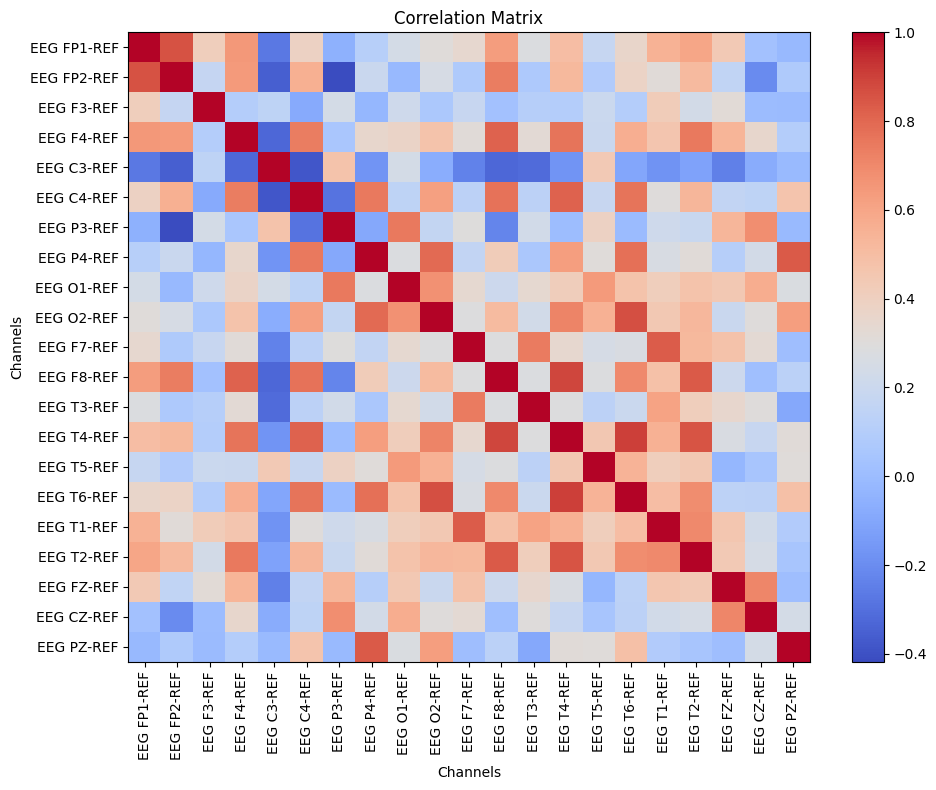

Standardized output shape: (23, 12, 21, 1250)
Correlation matrix shape: (23, 12, 21, 21)
(23, 12, 210)


In [416]:
# Standardize the data
X_train_standardized = standardize_data(X_train)
print(f"Standardized output shape: {X_train_standardized.shape}")
# Expected shape: (len(raw_files), 12, 21, 1250)
# Compute the correlation matrix per sample, segment, and channel

corr_matrix_train = compute_correlation_matrix(X_train_standardized)
print(f"Correlation matrix shape: {corr_matrix_train.shape}")
# Expected shape: (21, 21)
# Display the correlation matrix
plt.figure(figsize=(10, 8)) 
plt.imshow(corr_matrix_train[0][11], cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix')
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.xticks(range(len(eeg_cols)), eeg_cols, rotation=90)
plt.yticks(range(len(eeg_cols)), eeg_cols)
plt.tight_layout()
plt.show()

# Example usage
upper_triangle_matrix_train = extract_upper_triangle(corr_matrix_train)

# Standardize the data
X_test_standardized = standardize_data(X_test)
print(f"Standardized output shape: {X_test_standardized.shape}")
# Expected shape: (len(raw_files), 12, 21, 1250)
# Compute the correlation matrix per sample, segment, and channel

corr_matrix_test = compute_correlation_matrix(X_test_standardized)
print(f"Correlation matrix shape: {corr_matrix_test.shape}")
# Expected shape: (21, 21)

# Example usage
upper_triangle_matrix_test = extract_upper_triangle(corr_matrix_test)

print(upper_triangle_matrix_test.shape)

In [417]:
upper_triangle_matrix_train.shape

(104, 12, 210)

In [418]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(upper_triangle_matrix_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
# Create TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

X_test_tensor = torch.tensor(upper_triangle_matrix_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
# Create TensorDataset
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
# Create DataLoader
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [419]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)
print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([104, 12, 210])
torch.Size([23, 12, 210])
torch.Size([104])
torch.Size([23])


In [420]:
next(iter(train_loader))[0][0]

tensor([[0.7860, 0.8739, 0.5010,  ..., 0.6572, 0.0707, 0.6465],
        [0.7860, 0.8739, 0.5010,  ..., 0.6572, 0.0707, 0.6465],
        [0.7860, 0.8739, 0.5010,  ..., 0.6572, 0.0707, 0.6465],
        ...,
        [0.7860, 0.8739, 0.5010,  ..., 0.6572, 0.0707, 0.6465],
        [0.7860, 0.8739, 0.5010,  ..., 0.6572, 0.0707, 0.6465],
        [0.7860, 0.8739, 0.5010,  ..., 0.6572, 0.0707, 0.6465]])

## Load & transform Data

In [421]:
print(next(iter(train_loader))[0].shape)

torch.Size([8, 12, 210])


### Model Definition

Epoch 1/100, Train Loss: 0.7320, Val Loss: 0.6931, Val Accuracy: 51.92%
Epoch 2/100, Train Loss: 0.7050, Val Loss: 0.6857, Val Accuracy: 51.92%
Epoch 3/100, Train Loss: 0.7018, Val Loss: 0.6838, Val Accuracy: 51.92%
Epoch 4/100, Train Loss: 0.6909, Val Loss: 0.6762, Val Accuracy: 55.77%
Epoch 5/100, Train Loss: 0.6714, Val Loss: 0.6590, Val Accuracy: 58.65%
Epoch 6/100, Train Loss: 0.6792, Val Loss: 0.6439, Val Accuracy: 61.54%
Epoch 7/100, Train Loss: 0.6664, Val Loss: 0.6349, Val Accuracy: 66.35%
Epoch 8/100, Train Loss: 0.6537, Val Loss: 0.5900, Val Accuracy: 62.50%
Epoch 9/100, Train Loss: 0.6063, Val Loss: 0.5475, Val Accuracy: 74.04%
Epoch 10/100, Train Loss: 0.5944, Val Loss: 0.5112, Val Accuracy: 71.15%
Epoch 11/100, Train Loss: 0.5354, Val Loss: 0.5090, Val Accuracy: 70.19%
Epoch 12/100, Train Loss: 0.5383, Val Loss: 0.4773, Val Accuracy: 77.88%
Epoch 13/100, Train Loss: 0.4953, Val Loss: 0.6183, Val Accuracy: 66.35%
Epoch 14/100, Train Loss: 0.5974, Val Loss: 0.5018, Val Accu

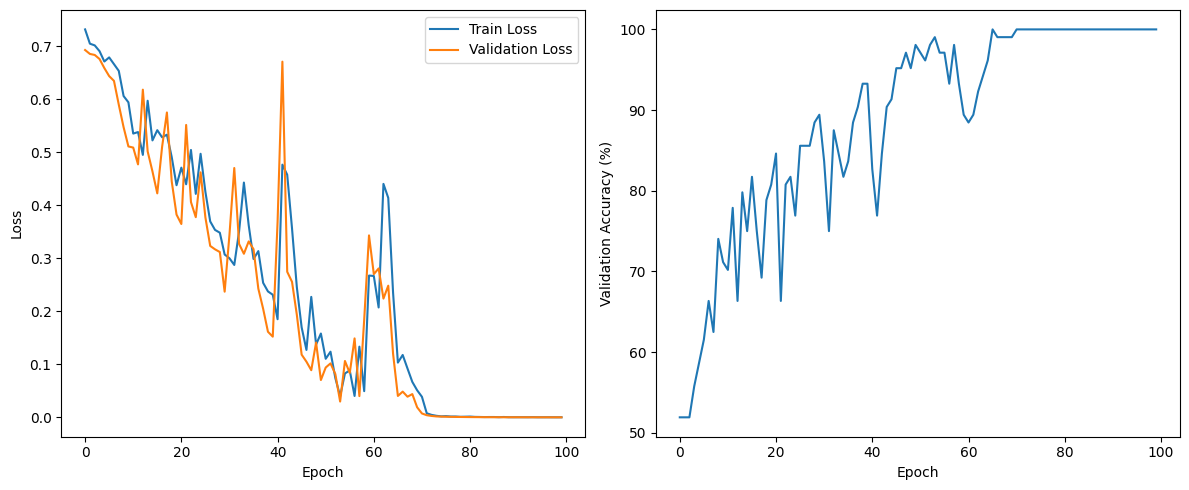

In [423]:

# Model parameters
input_dim = 210  # Size of flattened upper triangle (21*20/2)
embed_dim = 128  # Embedding dimension
num_heads = 4    # Number of attention heads

model = TimeSeriesAttentionClassifier(input_dim, embed_dim, num_heads)
# print(model)

# Train the model
train_losses, val_losses, val_accuracies = train_model(
    model, train_loader, train_loader, num_epochs=100
)

# Plot training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.tight_layout()
plt.show()

# Visualize attention for a sample
# visualize_attention(model, X_standardized)